<a href="https://colab.research.google.com/github/gawlowskiandrzej/Eksploracja_danych_projekt---detekcja-spamu/blob/main/spam_dataset_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Dataset Quality Analysis Notebook (Universal)

This notebook evaluates dataset quality using:
- Class separability (PCA)
- Lexical overlap (Jaccard similarity)
- Feature leakage (Chi-square)
- Entropy analysis
- Duplicate detection
- Baseline model sanity check


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from collections import Counter
from google.colab import files
import pandas as pd


In [65]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()


Saving phishing_dataset.csv to phishing_dataset (1).csv


,Text,Label
0,We noticed unusual sign-in activity on your Mi...,1
1,Your Apple ID has been used to sign in to iClo...,1
2,"Dear PayPal user, we've detected a potentially...",1
3,Your Netflix password was recently changed. If...,1
4,Action Required: Your Chase account has been t...,1


In [66]:
TEXT_COL = 'Text'
LABEL_COL = 'Label'

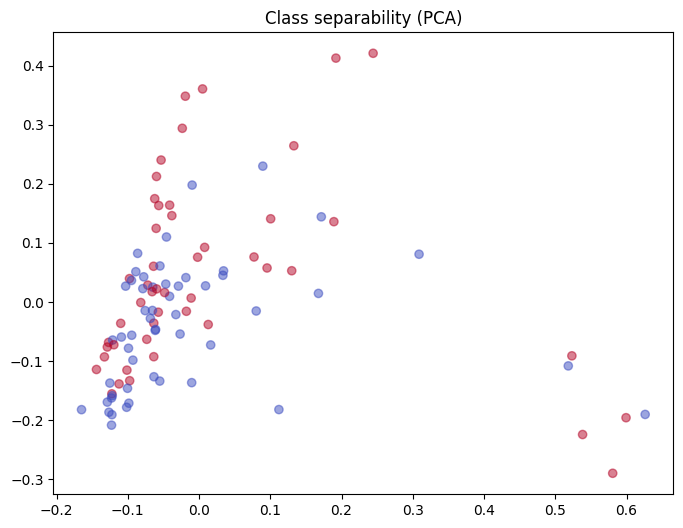

In [67]:
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(df[TEXT_COL])

X_pca = PCA(n_components=2).fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df[LABEL_COL], cmap='coolwarm', alpha=0.5)
plt.title('Class separability (PCA)')
plt.show()

In [68]:
spam_words = set(' '.join(df[df[LABEL_COL]==1][TEXT_COL]).lower().split())
ham_words = set(' '.join(df[df[LABEL_COL]==0][TEXT_COL]).lower().split())

jaccard = len(spam_words & ham_words) / len(spam_words | ham_words)
print('Jaccard similarity:', jaccard)

if jaccard < 0.2:
    print("🔴 Conclusion: very low lexical overlap → dataset may be overly easy and keyword-driven")
elif jaccard < 0.5:
    print("🟡 Conclusion: moderate lexical overlap → reasonably realistic dataset")
else:
    print("🟢 Conclusion: high lexical overlap → challenging dataset requiring semantic understanding")

Jaccard similarity: 0.21015067406819984
🟡 Conclusion: moderate lexical overlap → reasonably realistic dataset


In [69]:
cv = CountVectorizer(stop_words='english', min_df=5)
X_counts = cv.fit_transform(df[TEXT_COL])

chi_scores, _ = chi2(X_counts, df[LABEL_COL])
top_idx = chi_scores.argsort()[-20:]
features = np.array(cv.get_feature_names_out())[top_idx]

print('Top discriminative words:')
print(features)

keyword_hits = sum(f in ['free','win','click','urgent','offer'] for f in features)

if keyword_hits >= 10:
    print("🔴 Conclusion: strong reliance on keyword-based features → dataset is likely too easy")
elif keyword_hits >= 5:
    print("🟡 Conclusion: partially keyword-based patterns detected")
else:
    print("🟢 Conclusion: low keyword leakage → more realistic semantic dataset")

Top discriminative words:
['days' 'did' '24' 'details' 'subscription' 'know' 'let' 'need' 'secure'
 'password' 'week' 'april' 'update' 'just' 'hours' 'activity' 'verify'
 'link' 'information' 'click']
🟢 Conclusion: low keyword leakage → more realistic semantic dataset


In [70]:
def entropy(texts):
    words = ' '.join(texts).lower().split()
    freq = Counter(words)
    probs = np.array(list(freq.values())) / sum(freq.values())
    return -np.sum(probs * np.log2(probs))

spam_ent = entropy(df[df[LABEL_COL]==1][TEXT_COL])
ham_ent = entropy(df[df[LABEL_COL]==0][TEXT_COL])

print('Spam entropy:', spam_ent)
print('Ham entropy:', ham_ent)

if abs(spam_ent - ham_ent) < 0.2:
    print("🟢 Conclusion: similar linguistic complexity → balanced dataset")
elif spam_ent > ham_ent:
    print("🟡 Conclusion: spam messages are more diverse than ham")
else:
    print("🔴 Conclusion: strong entropy imbalance → possible dataset bias or synthetic artifacts")

Spam entropy: 8.376784763054678
Ham entropy: 8.489770744628087
🟢 Conclusion: similar linguistic complexity → balanced dataset


In [71]:
df['length'] = df[TEXT_COL].apply(len)
print(df.groupby(LABEL_COL)['length'].describe())

spam_mean = df[df[LABEL_COL]==1]['length'].mean()
ham_mean = df[df[LABEL_COL]==0]['length'].mean()

ratio = spam_mean / (ham_mean + 1e-6)

if 0.8 <= ratio <= 1.2:
    print("🟢 Conclusion: similar text lengths → realistic dataset structure")
elif ratio > 1.5:
    print("🟡 Conclusion: spam messages are significantly longer → possible structural bias")
else:
    print("🔴 Conclusion: strong length imbalance → dataset may be artificially separable")

       count        mean        std    min     25%    50%    75%    max
Label                                                                  
0       52.0  202.538462  24.096588  145.0  190.75  205.0  218.0  245.0
1       48.0  226.479167  22.881740  143.0  213.25  227.5  241.0  266.0
🟢 Conclusion: similar text lengths → realistic dataset structure


In [72]:
tfidf = TfidfVectorizer().fit_transform(df[TEXT_COL])
sim = cosine_similarity(tfidf)
np.fill_diagonal(sim, 0)

max_sim = sim.max()
print('Max similarity:', max_sim)

if max_sim > 0.9:
    print("🔴 Conclusion: very high duplication detected → dataset quality is low or synthetic")
elif max_sim > 0.75:
    print("🟡 Conclusion: moderate duplication present → reduced diversity")
else:
    print("🟢 Conclusion: low duplication → good dataset diversity")

Max similarity: 0.6533889154968026
🟢 Conclusion: low duplication → good dataset diversity


In [73]:
model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X, df[LABEL_COL], cv=5)

acc = scores.mean()
print('CV accuracy:', acc)

if acc > 0.95:
    print("🔴 Conclusion: extremely high accuracy → likely feature leakage or overly easy dataset")
elif acc > 0.85:
    print("🟡 Conclusion: moderate accuracy → partially learnable patterns")
else:
    print("🟢 Conclusion: lower accuracy → requires deeper semantic understanding")

CV accuracy: 0.6100000000000001
🟢 Conclusion: lower accuracy → requires deeper semantic understanding
